In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_samples = 1000

data = {
    'shipment_id': range(1, n_samples + 1),
    'supplier_rating': np.random.uniform(3.0, 5.0, n_samples),
    'distance_miles': np.random.randint(500, 5000, n_samples),
    'weather_risk_index': np.random.uniform(0, 1, n_samples),
    'historical_lead_time': np.random.randint(5, 30, n_samples),
}

df = pd.DataFrame(data)
# Create a logical target variable: delays increase with lower supplier ratings and high weather risk
df['actual_delay_days'] = (
    (5 / df['supplier_rating']) 
    + (df['distance_miles'] / 1000) 
    + (df['weather_risk_index'] * 7) 
    + np.random.normal(0, 2, n_samples)
).round().astype(int)

# Ensure no negative delays
df['actual_delay_days'] = df['actual_delay_days'].clip(lower=0)
df.to_csv('Downloads/historical_shipments.csv', index=False)
print("Mock data generated successfully!")

Mock data generated successfully!


In [2]:
from sklearn.model_selection import train_test_split

# Features (X) and Target (y)
X = df[['supplier_rating', 'distance_miles', 'weather_risk_index', 'historical_lead_time']]
y = df['actual_delay_days']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from xgboost import XGBRegressor

# Create model
model = XGBRegressor()

# Train model
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [5]:
y_pred = model.predict(X_test)

In [6]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.853426218032837
R2 Score: 0.4472268223762512


In [7]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import joblib

# Load data
df = pd.read_csv('C:/Users/GEETHA/Downloads/historical_shipments.csv')
X = df[['supplier_rating', 'distance_miles', 'weather_risk_index', 'historical_lead_time']]
y = df['actual_delay_days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Model Baseline Trained. Root Mean Squared Error: {rmse:.2f} days")

# Save model artifact
import os

os.makedirs('ml_engine', exist_ok=True)
joblib.dump(model, 'ml_engine/xgboost_delay_model.pkl')

Model Baseline Trained. Root Mean Squared Error: 2.19 days


['ml_engine/xgboost_delay_model.pkl']

In [8]:
!pip install fastapi uvicorn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import numpy as np

app = FastAPI(title="SupplyPrescript Engine")

# Load the trained model artifact
model = joblib.load('ml_engine/xgboost_delay_model.pkl')

class ShipmentFeatures(BaseModel):
    supplier_rating: float
    distance_miles: int
    weather_risk_index: float
    historical_lead_time: int

@app.get("/")
def root():
    return {"status": "SupplyPrescript API running"}

@app.post("/predict-delay/")
def predict_delay(features: ShipmentFeatures):
    try:
        input_data = np.array([[
            features.supplier_rating,
            features.distance_miles,
            features.weather_risk_index,
            features.historical_lead_time
        ]])
        predicted_delay = model.predict(input_data)[0]
        return {"predicted_delay_days": max(0, float(round(predicted_delay, 1)))}
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

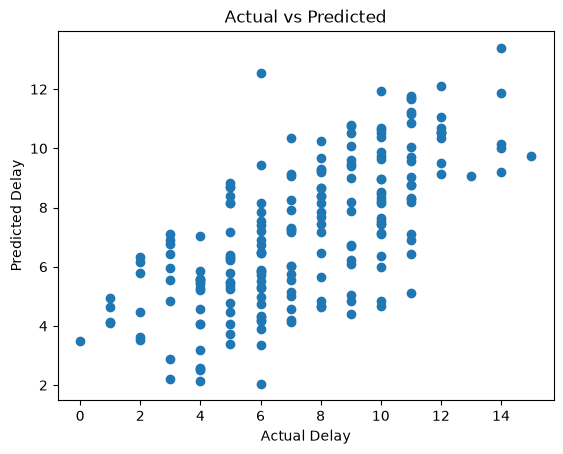

In [10]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")
plt.title("Actual vs Predicted")
plt.show()